# EDA: денситометрия (DXA), НД_для_обучения

Ноутбук делает три вещи:
1. **Визуализация любого файла/исследования**: функции `show_file(path)`, `show_study(study)`, `show_gallery(criterion)`.
2. **Разбор структуры данных**: сколько снимков в исследовании, какие из них дубликаты и какой снимок какой области соответствует.
3. **Базовый EDA разметки**: распределение нарушений, их совместная встречаемость, комментарии экспертов.

In [2]:
import warnings, hashlib, logging
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
logging.getLogger('pydicom').setLevel(logging.ERROR)  # в файлах невалидные UID (1.2.643...), pydicom ругается
pd.set_option('display.width', 200, 'display.max_columns', 40, 'display.max_colwidth', 60)

DATA = Path('../НД_для_обучения')
STUDIES = DATA / 'Исследования'
LABELS = DATA / 'разметка.xlsx'

## 1. Инвентаризация DICOM-файлов

In [3]:
def read_meta(path):
    d = pydicom.dcmread(path)
    px = d.pixel_array
    rel = path.relative_to(STUDIES)
    return dict(
        path=str(path),
        study=rel.parts[0],                 # имя папки = ключ в разметка.xlsx
        series_dir=rel.parts[1],
        study_uid_tag=str(d.get('StudyInstanceUID', '')),
        sop_uid=str(d.get('SOPInstanceUID', '')),
        instance=int(d.get('InstanceNumber', -1)),
        rows=px.shape[0], cols=px.shape[1],
        exposed_area=str(d.get('ExposedArea', '')),
        entrance_dose=float(d.get('EntranceDoseInmGy', np.nan) or np.nan),
        px_min=int(px.min()), px_max=int(px.max()),
        px_mean=float(px.mean()), frac_zero=float((px == 0).mean()),
        px_hash=hashlib.md5(px.tobytes()).hexdigest(),
    )

files = sorted(STUDIES.rglob('*.dcm'))
meta = pd.DataFrame([read_meta(f) for f in files])
print(f'{len(files)} файлов, {meta.study.nunique()} исследований')
print('Имя папки == StudyInstanceUID в теге:', (meta.study == meta.study_uid_tag).mean())
meta.head()

499 файлов, 100 исследований
Имя папки == StudyInstanceUID в теге: 0.0


,path,study,series_dir,study_uid_tag,sop_uid,instance,rows,cols,exposed_area,entrance_dose,px_min,px_max,px_mean,frac_zero,px_hash
0,../НД_для_обучения/Исследования/1.2.840.113619.2.110.512...,1.2.840.113619.2.110.512719.20250403090444,series_004_3_CR,1.2.643.5.1.13.13.12.2.77.8252.0811070309131015060509090...,1.2.643.5.1.13.13.12.2.77.8252.1403101509100803101304020...,1,289,300,"[180, 175]",0.074,0,252,48.538997,0.426378,62c631f07b242099893df91ffceb7a4f
1,../НД_для_обучения/Исследования/1.2.840.113619.2.110.512...,1.2.840.113619.2.110.512719.20250403090444,series_004_3_CR,1.2.643.5.1.13.13.12.2.77.8252.0811070309131015060509090...,1.2.643.5.1.13.13.12.2.77.8252.0303081115120115150205061...,8,235,280,"[170, 143]",0.037,0,252,44.754559,0.538647,8feee3d90284b5919cfe3dffde2fa651
2,../НД_для_обучения/Исследования/1.2.840.113619.2.110.512...,1.2.840.113619.2.110.512719.20250403090444,series_004_3_CR,1.2.643.5.1.13.13.12.2.77.8252.0811070309131015060509090...,1.2.643.5.1.13.13.12.2.77.8252.0600081210110614121304140...,4,263,280,"[520, 478]",0.148,0,252,44.310660,0.550665,fe69d2d49a6230809c0c446814d7b5ea
3,../НД_для_обучения/Исследования/1.2.840.113619.2.110.512...,1.2.840.113619.2.110.512719.20250403090444,series_004_3_CR,1.2.643.5.1.13.13.12.2.77.8252.0811070309131015060509090...,1.2.643.5.1.13.13.12.2.77.8252.1013020902150305001309030...,6,263,280,"[170, 160]",0.037,0,252,44.310660,0.550665,fe69d2d49a6230809c0c446814d7b5ea
4,../НД_для_обучения/Исследования/1.2.840.113619.2.110.512...,1.2.840.113619.2.110.512719.20250403090444,series_004_3_CR,1.2.643.5.1.13.13.12.2.77.8252.0811070309131015060509090...,1.2.643.5.1.13.13.12.2.77.8252.1301110509130908000813051...,5,235,280,"[520, 478]",0.148,0,252,44.754559,0.538647,8feee3d90284b5919cfe3dffde2fa651


In [4]:
# Общие для всех файлов теги
d0 = pydicom.dcmread(files[0], stop_before_pixels=True)
for kw in ['Modality', 'Manufacturer', 'ManufacturerModelName', 'SOPClassUID', 'PhotometricInterpretation',
           'BitsStored', 'PixelSpacing', 'BodyPartExamined', 'Laterality', 'ViewPosition', 'SeriesDescription']:
    print(f'{kw:28s}', repr(d0.get(kw, '<нет>')))

Modality                     'CR'
Manufacturer                 'GE Healthcare'
ManufacturerModelName        'Lunar Prodigy Advance'
SOPClassUID                  '1.2.840.10008.5.1.4.1.1.1'
PhotometricInterpretation    'MONOCHROME2'
BitsStored                   8
PixelSpacing                 '<нет>'
BodyPartExamined             ''
Laterality                   ''
ViewPosition                 ''
SeriesDescription            'Изображения DXA'


## 2. Сколько снимков в исследовании и сколько из них дубликаты

Файлов в исследовании от 1 до 29. После дедупликации по хешу пикселей уникальных снимков **не больше 3**:
позвоночник, правое бедро и левое бедро. Остальное — повторные выгрузки тех же изображений с другим `InstanceNumber`/`SOPInstanceUID`.

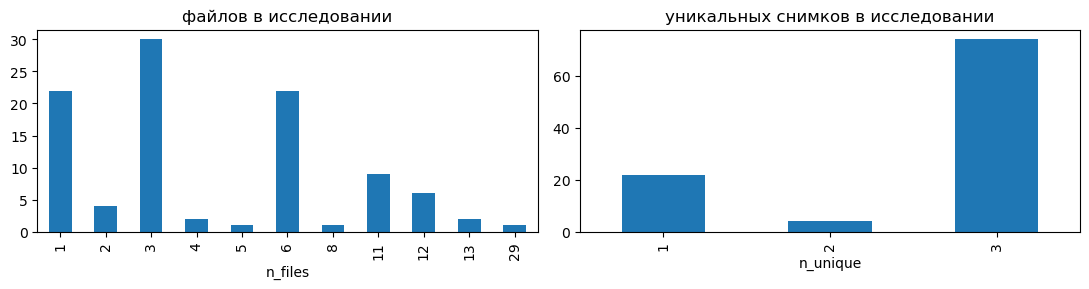

Дубликатов между разными исследованиями: 0


In [5]:
per_study = meta.groupby('study').agg(n_files=('path', 'size'), n_unique=('px_hash', 'nunique'))
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
per_study.n_files.value_counts().sort_index().plot.bar(ax=ax[0], title='файлов в исследовании')
per_study.n_unique.value_counts().sort_index().plot.bar(ax=ax[1], title='уникальных снимков в исследовании')
plt.tight_layout(); plt.show()
print('Дубликатов между разными исследованиями:',
      meta.drop_duplicates(['study', 'px_hash']).px_hash.duplicated().sum())

In [6]:
# Уникальные снимки: берём первый по InstanceNumber
img = (meta.sort_values(['study', 'instance'])
           .drop_duplicates(['study', 'px_hash'])
           .reset_index(drop=True))
img['n_copies'] = img.merge(meta.groupby(['study', 'px_hash']).size().rename('k'),
                            on=['study', 'px_hash']).k
print(len(img), 'уникальных снимков')

252 уникальных снимков


## 3. Определение области (позвоночник / правое / левое бедро)

В DICOM нет ни `BodyPartExamined`, ни `Laterality`, ни `PixelSpacing`, поэтому область определяем эвристикой:
- **ширина 300 px → позвоночник**, 280 (или 248) px → бедро;
- **сторона бедра**: головка бедра и таз дают яркую верхнюю половину со стороны головки. Если верхняя треть ярче слева, это левое бедро, если справа — правое.

Ниже эвристика сверяется с разметкой: у области, снимок которой отсутствует, в xlsx стоит NaN.

In [7]:
def guess_region(px):
    h, w = px.shape
    if w >= 300:
        return 'spine'
    top = px[: h // 3].astype(float)
    return 'lhip' if top[:, : w // 2].mean() > top[:, w // 2 :].mean() else 'rhip'

def load_px(path):
    return pydicom.dcmread(path).pixel_array

img['region'] = [guess_region(load_px(p)) for p in img.path]
pd.crosstab(img.cols, img.region)

region,lhip,rhip,spine
cols,,,
248,1,1,0
280,78,73,0
300,0,0,99


## 4. Разметка

In [9]:
raw = pd.read_excel(LABELS, header=None)
lab = raw.iloc[2:, :13].copy()
lab.columns = ['n', 'study',
               'spine_position', 'spine_axis', 'spine_artifacts',
               'rhip_rotation', 'rhip_roi',
               'lhip_rotation', 'lhip_roi',
               'spine_bad', 'rhip_bad', 'lhip_bad', 'comment']
lab = lab.drop(columns='n').reset_index(drop=True)
CRIT = lab.columns[1:11].tolist()
lab[CRIT] = lab[CRIT].apply(pd.to_numeric, errors='coerce')
REGION_CRIT = {'spine': ['spine_position', 'spine_axis', 'spine_artifacts'],
               'rhip': ['rhip_rotation', 'rhip_roi'],
               'lhip': ['lhip_rotation', 'lhip_roi']}
print('Столбцы 13–18 xlsx — сводка эксперта (50 норма / 50 патология), их не используем')
lab.head()

Столбцы 13–18 xlsx — сводка эксперта (50 норма / 50 патология), их не используем


,study,spine_position,spine_axis,spine_artifacts,rhip_rotation,rhip_roi,lhip_rotation,lhip_roi,spine_bad,rhip_bad,lhip_bad,comment
0,2.25.306921081709806079165809721263236241032,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,2.25.307021710202910067378603383388989711646,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN
2,2.25.309085571913348252136520206003694446566,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN
3,2.25.314147167453134440746270747484612743945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,2.25.338439598607961312040815816824093323492,0.0,0.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,сколиоз


In [10]:
# Проверка эвристики: множество найденных областей == множеству размеченных областей
found = img.groupby('study').region.apply(lambda s: set(s))
labeled = lab.set_index('study').apply(lambda r: {k for k in REGION_CRIT if pd.notna(r[k + '_bad'])}, axis=1)
chk = pd.DataFrame({'found': found, 'labeled': labeled})
chk['ok'] = chk.found == chk.labeled
print('Совпадение областей:', chk.ok.sum(), '/', len(chk))
chk[~chk.ok].join(lab.set_index('study').comment)

Совпадение областей: 98 / 100


,found,labeled,ok,comment
study,,,,
2.25.11175860580562939441493697221497597640,"{rhip, lhip, spine}","{lhip, spine}",False,правое бедро эндопротезирования
2.25.12798473087614376830819854616447908612,"{rhip, lhip, spine}",{spine},False,эндопротезирования ТБС


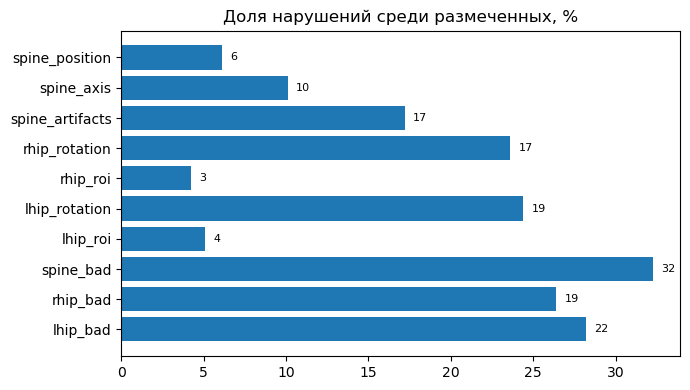

,n_labeled,n_violation,rate_%
spine_position,99,6,6.1
spine_axis,99,10,10.1
spine_artifacts,99,17,17.2
rhip_rotation,72,17,23.6
rhip_roi,72,3,4.2
lhip_rotation,78,19,24.4
lhip_roi,78,4,5.1
spine_bad,99,32,32.3
rhip_bad,72,19,26.4
lhip_bad,78,22,28.2


In [11]:
# Распределение нарушений по критериям
dist = pd.DataFrame({
    'n_labeled': lab[CRIT].notna().sum(),
    'n_violation': (lab[CRIT] == 1).sum(),
})
dist['rate_%'] = (100 * dist.n_violation / dist.n_labeled).round(1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(dist.index, dist['rate_%']); ax.invert_yaxis(); ax.set_title('Доля нарушений среди размеченных, %')
for i, (v, n) in enumerate(zip(dist['rate_%'], dist.n_violation)):
    ax.text(v + 0.5, i, f'{n}', va='center', fontsize=8)
plt.tight_layout(); plt.show()
dist

In [12]:
# Согласованность: итог по области == OR критериев?
for reg, cs in REGION_CRIT.items():
    bad = lab[reg + '_bad']
    any_c = lab[cs].max(axis=1)
    mism = lab[bad.notna() & (any_c != bad)]
    print(f'{reg}: несовпадений {len(mism)}')
    if len(mism):
        display(mism[['study'] + cs + [reg + '_bad', 'comment']])

spine: несовпадений 3


,study,spine_position,spine_axis,spine_artifacts,spine_bad,comment
5,2.25.339027809107632348165171236474821772940,0.0,0.0,0.0,1.0,сколиоз
10,2.25.52532476139575422857225834315571570912,0.0,0.0,0.0,1.0,"Сколиоз, не верня разметка"
34,2.25.127126130998341190348103034690069487890,0.0,1.0,0.0,0.0,перелом


rhip: несовпадений 0
lhip: несовпадений 0


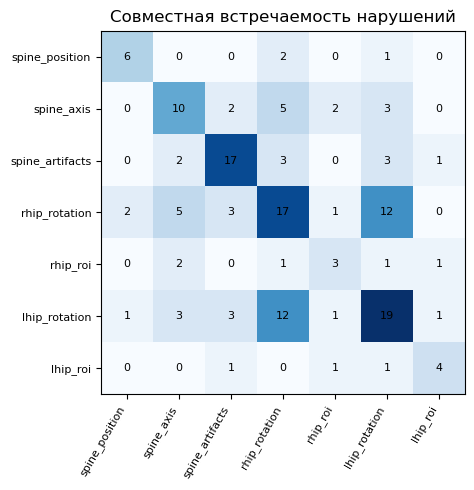

Число нарушений на исследование:
0.0    52
1.0    28
2.0    14
3.0     4
4.0     2
Name: count, dtype: int64

Есть хоть одно нарушение: 48 / 100


In [13]:
# Совместная встречаемость нарушений (мультилейбл)
V = lab[CRIT[:7]].fillna(0)
co = V.T @ V
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(co, cmap='Blues')
ax.set_xticks(range(7), co.columns, rotation=60, ha='right', fontsize=8)
ax.set_yticks(range(7), co.index, fontsize=8)
for i in range(7):
    for j in range(7):
        ax.text(j, i, int(co.iloc[i, j]), ha='center', va='center', fontsize=8)
ax.set_title('Совместная встречаемость нарушений'); plt.tight_layout(); plt.show()

print('Число нарушений на исследование:'); print(V.sum(axis=1).value_counts().sort_index())
print('\nЕсть хоть одно нарушение:', (V.sum(axis=1) > 0).sum(), '/', len(V))

In [14]:
lab.comment.value_counts()

comment
сколиоз                                      13
Требует внимание                              2
Хороший пример отклонения оси при КТ п-ка     1
Сколиоз, не верня разметка                    1
L6, люмбализация                              1
Отклонение оси, нет малых вертелов            1
Хороший пример ротации                        1
перелом                                       1
правое бедро эндопротезирования               1
эндопротезирования ТБС                        1
Name: count, dtype: int64

## 5. Свойства изображений по областям

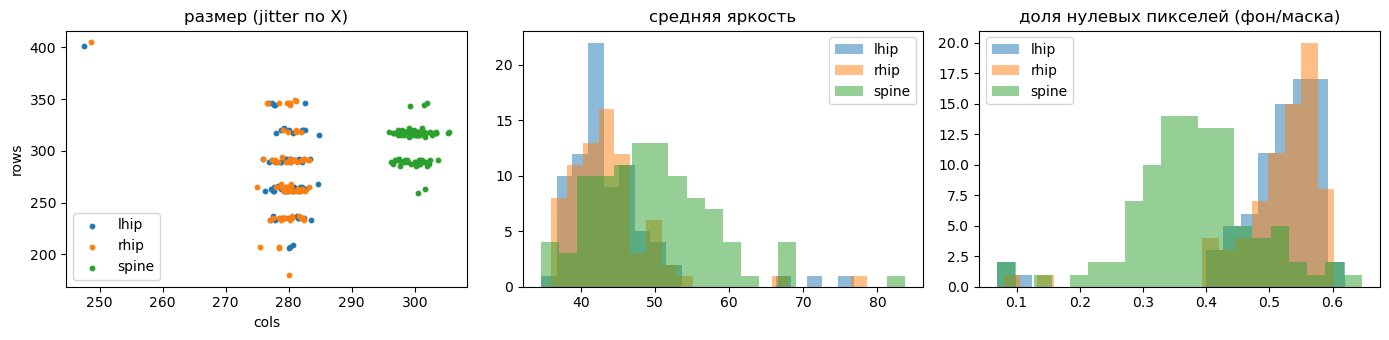

region                 lhip    rhip   spine
rows          count   79.00   74.00   99.00
              mean   276.56  275.08  306.57
              std     37.19   41.16   16.36
              min    206.00  180.00  259.00
              25%    261.00  237.00  289.00
              50%    265.00  265.00  315.00
              75%    292.00  291.00  318.00
              max    401.00  405.00  346.00
cols          count   79.00   74.00   99.00
              mean   279.59  279.57  300.00
              std      3.60    3.72    0.00
              min    248.00  248.00  300.00
              25%    280.00  280.00  300.00
              50%    280.00  280.00  300.00
              75%    280.00  280.00  300.00
              max    280.00  280.00  300.00
px_mean       count   79.00   74.00   99.00
              mean    44.12   44.05   49.73
              std      6.70    6.28    8.28
              min     34.64   36.04   34.60
              25%     40.79   40.16   44.17
              50%     42.73   43.11   49.00
              75%     45.66   45.82   54.20
              max     76.81   78.52   83.74
frac_zero     count   79.00   74.00   99.00
              mean     0.51    0.51    0.38
              std      0.10    0.08    0.10
              min      0.07    0.08    0.07
              25%      0.50    0.49    0.33
              50%      0.53    0.53    0.38
              75%      0.56    0.56    0.43
              max      0.62    0.60    0.65
entrance_dose count   78.00   72.00   99.00
              mean     0.09    0.09    0.08
              std      0.06    0.06    0.05
              min      0.01    0.01    0.04
              25%      0.04    0.04    0.04
              50%      0.07    0.07    0.07
              75%      0.14    0.15    0.10
              max      0.28    0.28    0.28

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
for reg, g in img.groupby('region'):
    ax[0].scatter(g.cols + np.random.randn(len(g)) * 2, g.rows, s=10, label=reg)
    ax[1].hist(g.px_mean, bins=20, alpha=.5, label=reg)
    ax[2].hist(g.frac_zero, bins=20, alpha=.5, label=reg)
ax[0].set(xlabel='cols', ylabel='rows', title='размер (jitter по X)')
ax[1].set_title('средняя яркость'); ax[2].set_title('доля нулевых пикселей (фон/маска)')
for a in ax: a.legend()
plt.tight_layout(); plt.show()
img.groupby('region')[['rows', 'cols', 'px_mean', 'frac_zero', 'entrance_dose']].describe().T.round(2)

## 6. Визуализация

- `show_file(path)` — любой .dcm (путь абсолютный или относительный к `Исследования/`), с тегами;
- `show_study(study)` — все уникальные снимки исследования с метками эксперта (study можно указать префиксом или хвостом UID);
- `show_gallery(criterion, value)` — примеры с заданной меткой по критерию.

In [16]:
def _resolve(path):
    p = Path(path)
    return p if p.exists() else STUDIES / p

def show_file(path, tags=True, ax=None):
    p = _resolve(path)
    d = pydicom.dcmread(p)
    px = d.pixel_array
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(px, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{p.name}  {px.shape}  region≈{guess_region(px)}', fontsize=9)
    ax.axis('off')
    if tags:
        for kw in ['StudyInstanceUID', 'SOPInstanceUID', 'InstanceNumber', 'SeriesNumber',
                   'ExposedArea', 'EntranceDoseInmGy', 'PatientOrientation']:
            print(f'{kw:20s} {d.get(kw, "")}')
    return px

def find_study(key):
    hits = [s for s in lab.study if s == key or s.startswith(key) or s.endswith(key)]
    assert len(hits) == 1, f'найдено {len(hits)}: {hits[:5]}'
    return hits[0]

def show_study(key, all_files=False):
    st = find_study(key)
    rows = (meta if all_files else img)[lambda x: x.study == st].sort_values('instance')
    l = lab.set_index('study').loc[st]
    fig, axs = plt.subplots(1, len(rows), figsize=(4.5 * len(rows), 5), squeeze=False)
    for ax, (_, r) in zip(axs[0], rows.iterrows()):
        px = load_px(r.path)
        reg = guess_region(px)
        ax.imshow(px, cmap='gray', vmin=0, vmax=255); ax.axis('off')
        crit = '\n'.join(f'{c}={l[c]:.0f}' if pd.notna(l[c]) else f'{c}=—' for c in REGION_CRIT[reg])
        ax.set_title(f'inst {r.instance} | {reg} | bad={l[reg + "_bad"]}\n{crit}', fontsize=9)
    fig.suptitle(f'{st}   comment: {l.comment if pd.notna(l.comment) else ""}', fontsize=9)
    plt.tight_layout(); plt.show()

def show_gallery(criterion, value=1, n=8, seed=0):
    reg = criterion.split('_')[0]
    studies = lab[lab[criterion] == value].study
    sub = img[img.study.isin(studies) & (img.region == reg)].sample(frac=1, random_state=seed).head(n)
    fig, axs = plt.subplots(1, len(sub), figsize=(3 * len(sub), 3.5), squeeze=False)
    for ax, (_, r) in zip(axs[0], sub.iterrows()):
        ax.imshow(load_px(r.path), cmap='gray', vmin=0, vmax=255); ax.axis('off')
        ax.set_title(r.study[-8:], fontsize=8)
    fig.suptitle(f'{criterion} = {value}  ({len(studies)} исследований)'); plt.tight_layout(); plt.show()

StudyInstanceUID     1.2.643.5.1.13.13.12.2.77.8252.09130409131001141403120204031509
SOPInstanceUID       1.2.643.5.1.13.13.12.2.77.8252.07111115111305011108141412010801
InstanceNumber       1
SeriesNumber         2
ExposedArea          [180, 193]
EntranceDoseInmGy    0.166000
PatientOrientation   ['L', 'F']


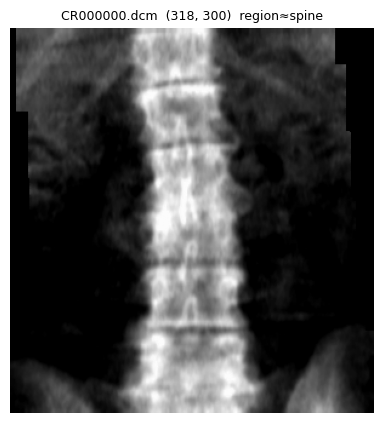

In [26]:
# Пример: любой файл
_ = show_file(files[81])

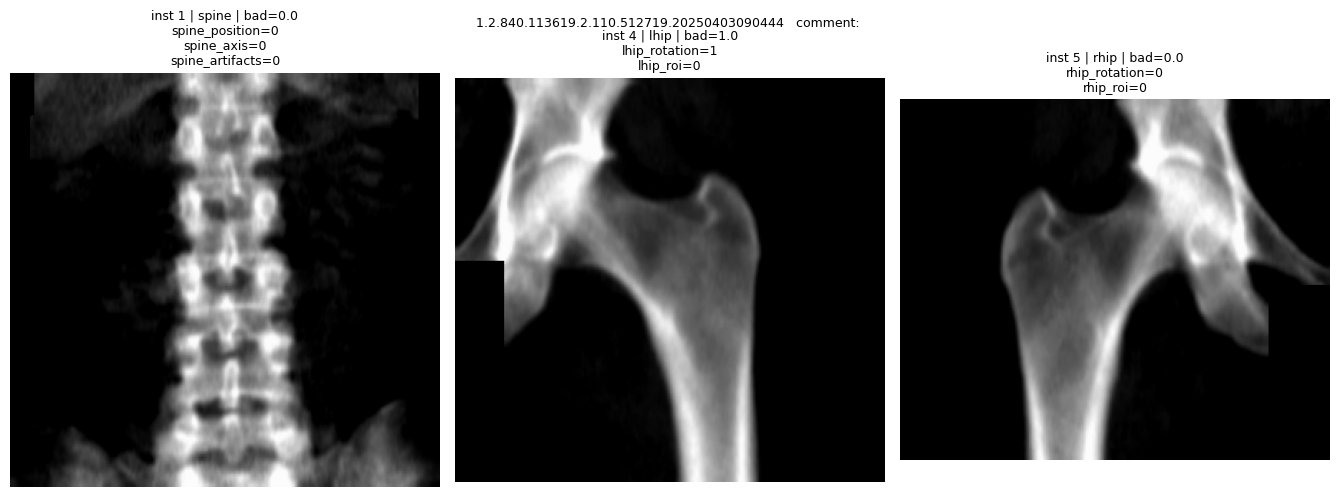

In [23]:
# Пример: исследование по хвосту UID (с метками эксперта)
show_study('20250403090444')

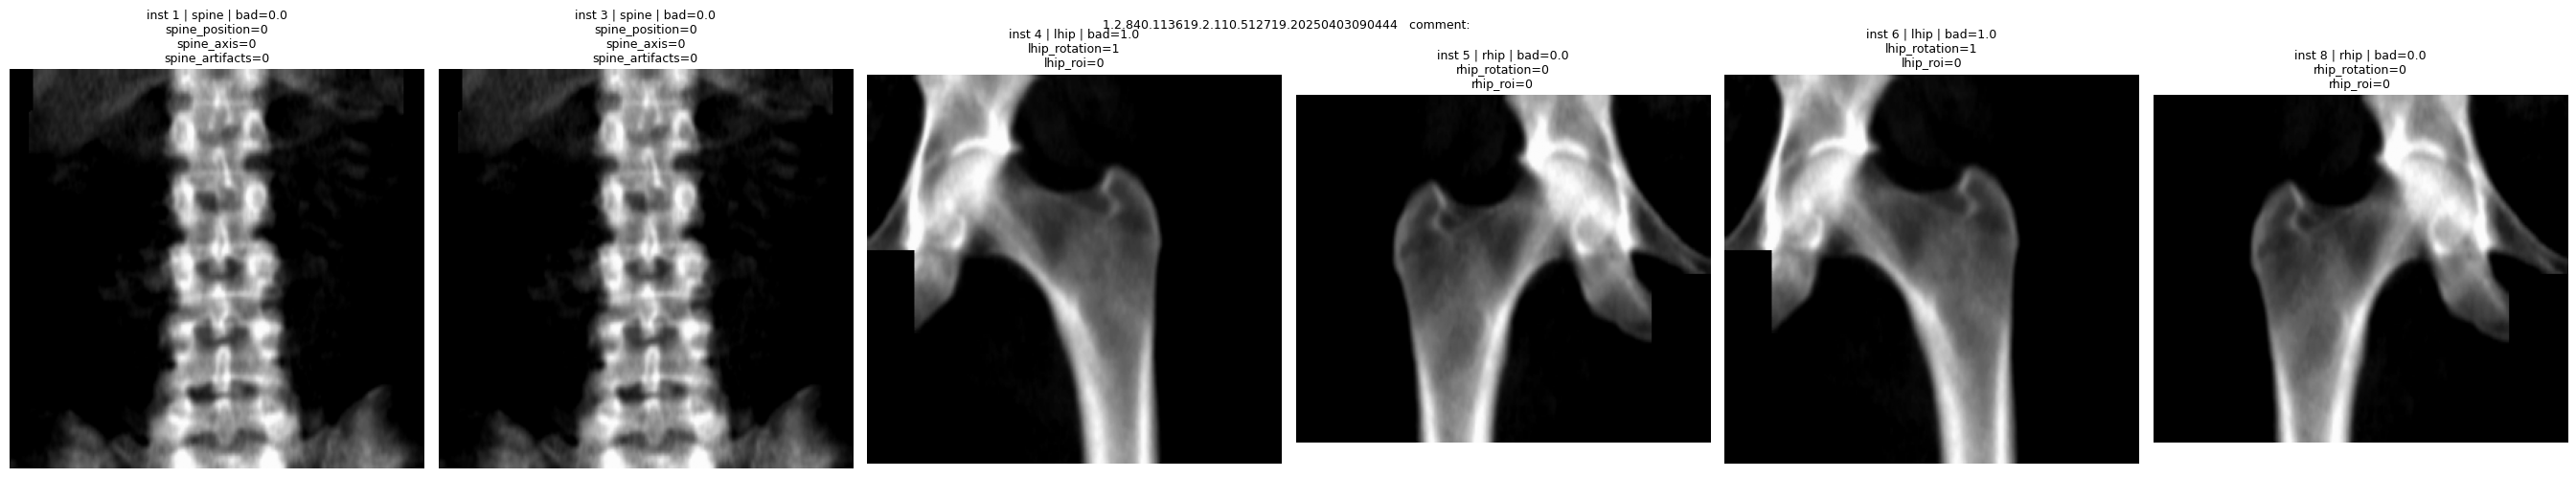

In [24]:
# То же исследование со всеми файлами, включая дубликаты
show_study('20250403090444', all_files=True)

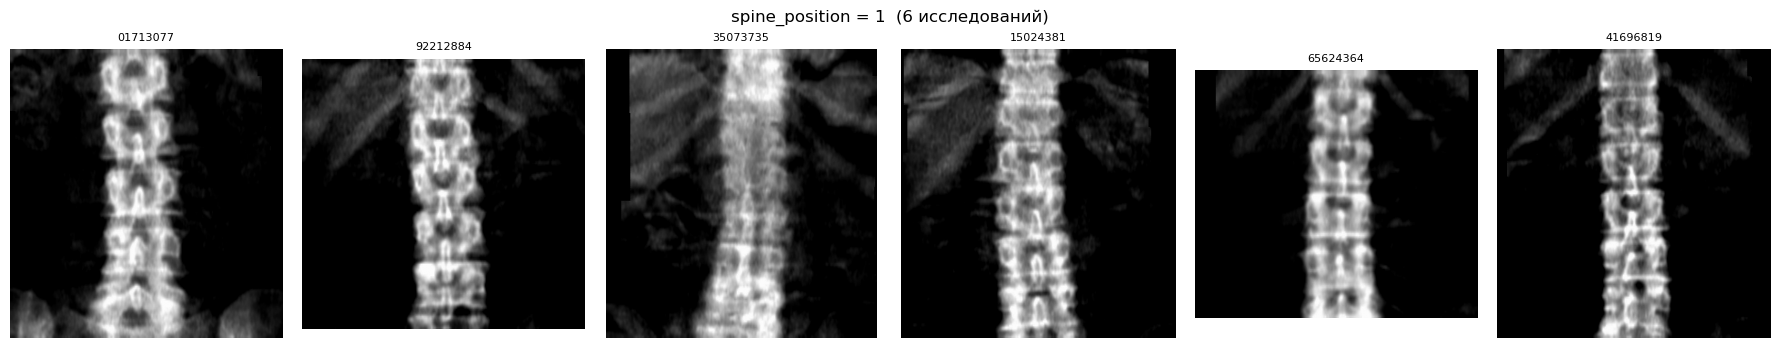

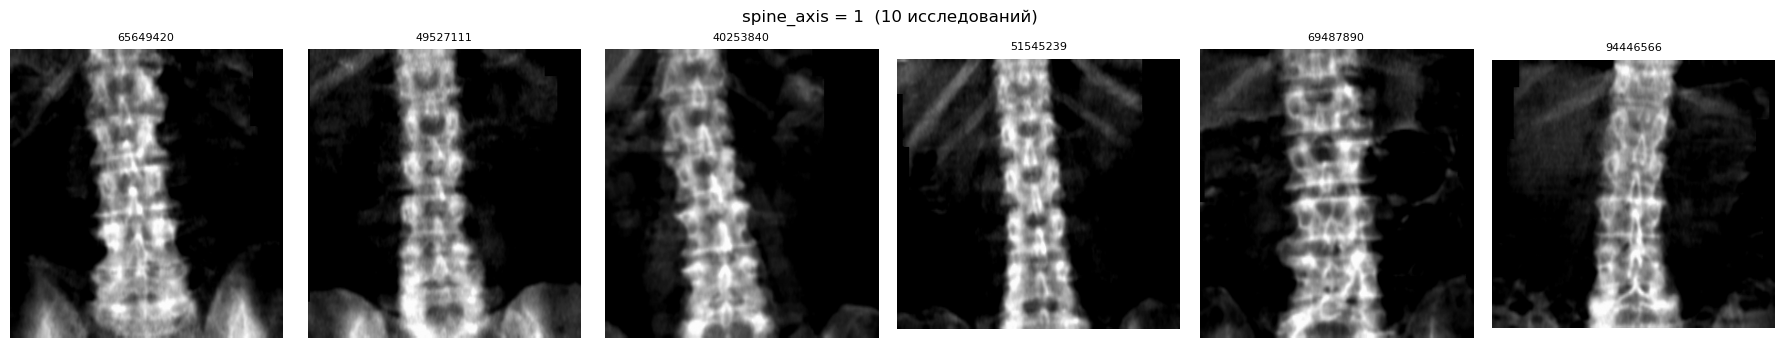

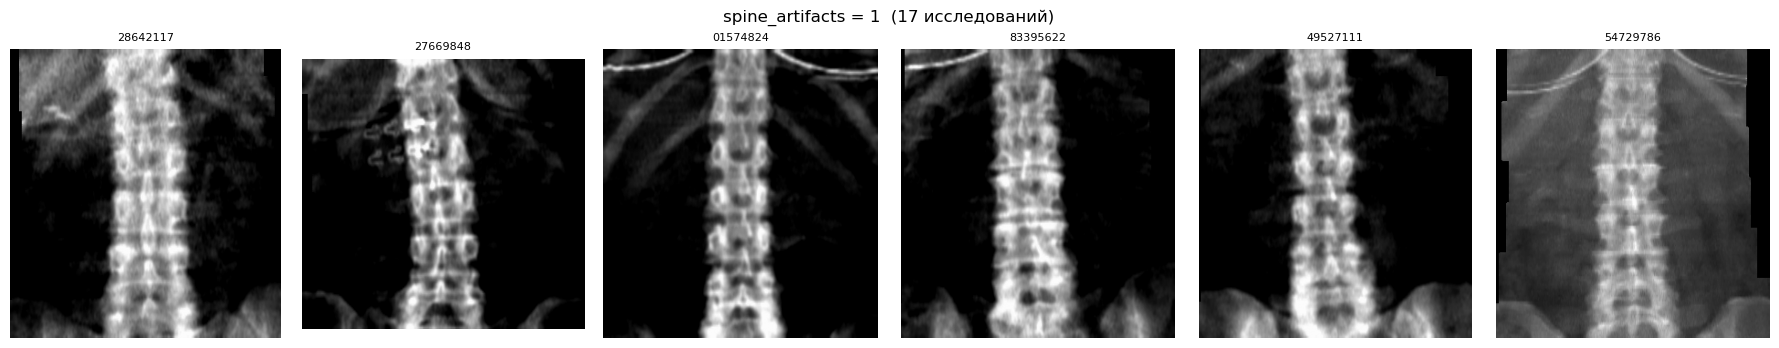

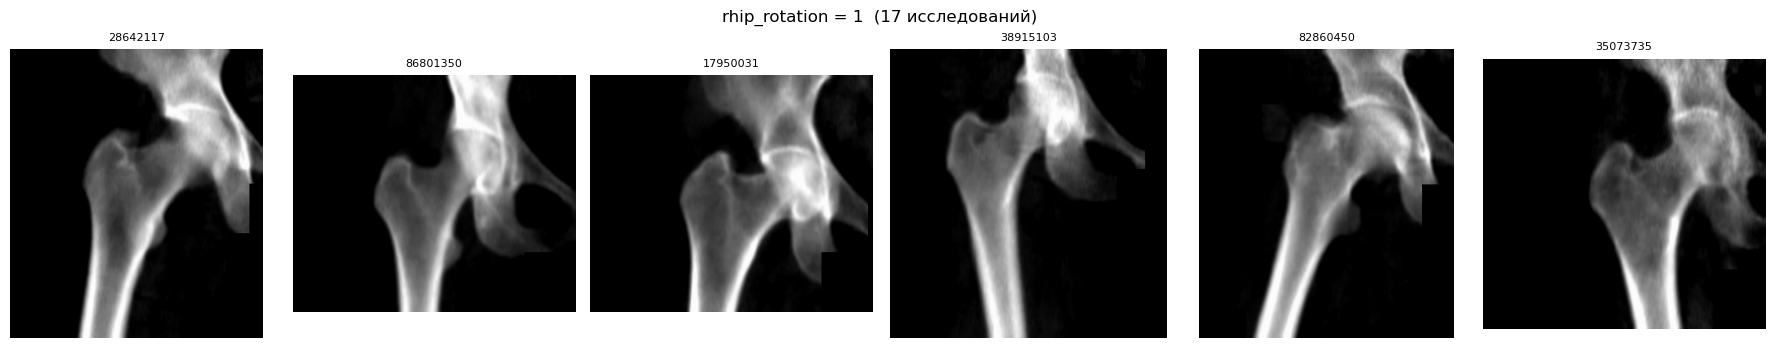

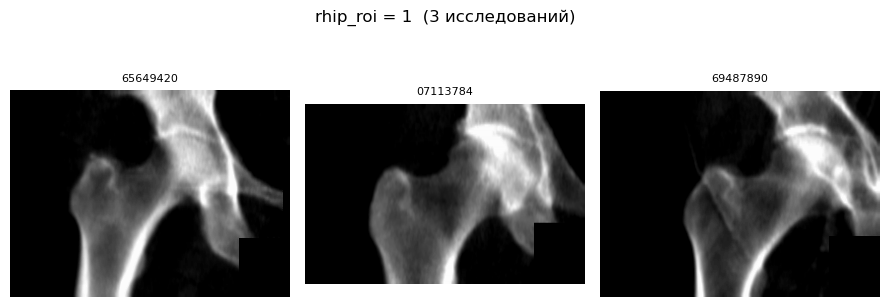

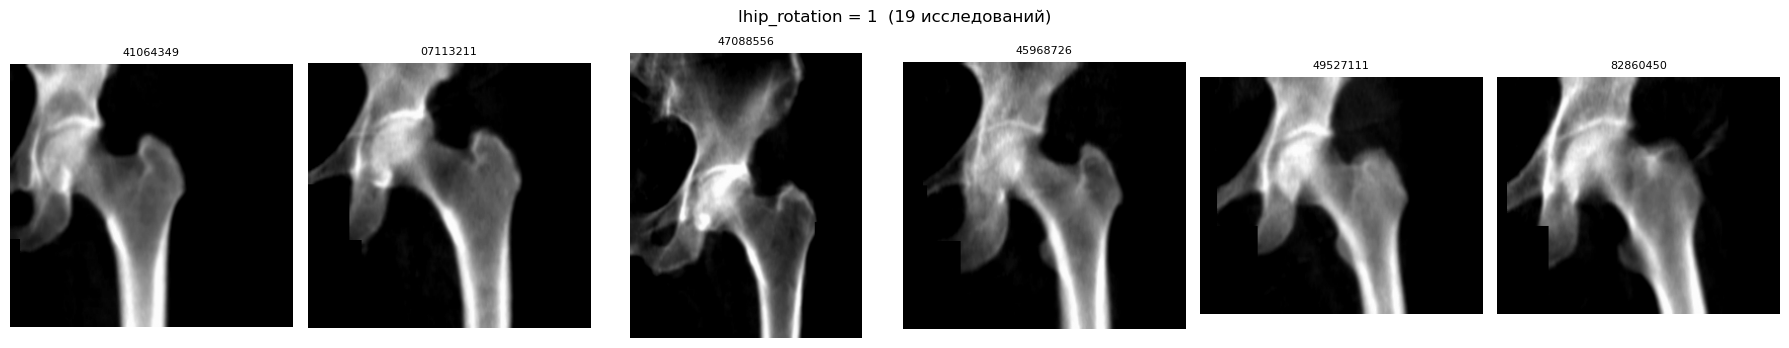

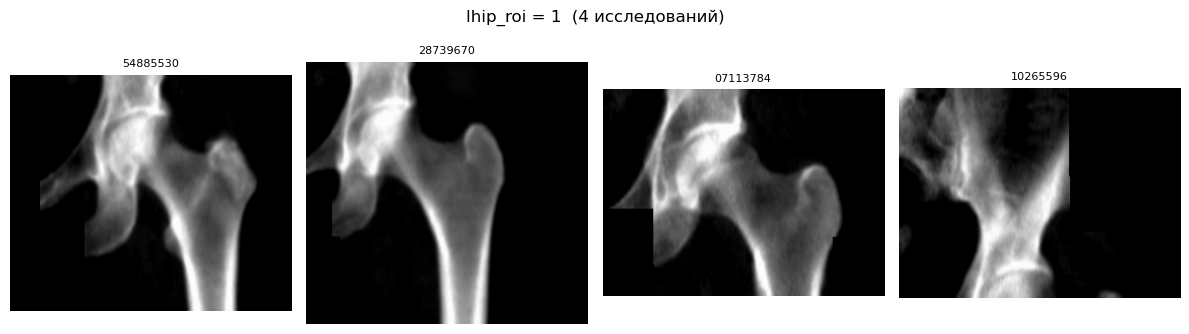

In [25]:
for c in CRIT[:7]:
    show_gallery(c, 1, n=6)

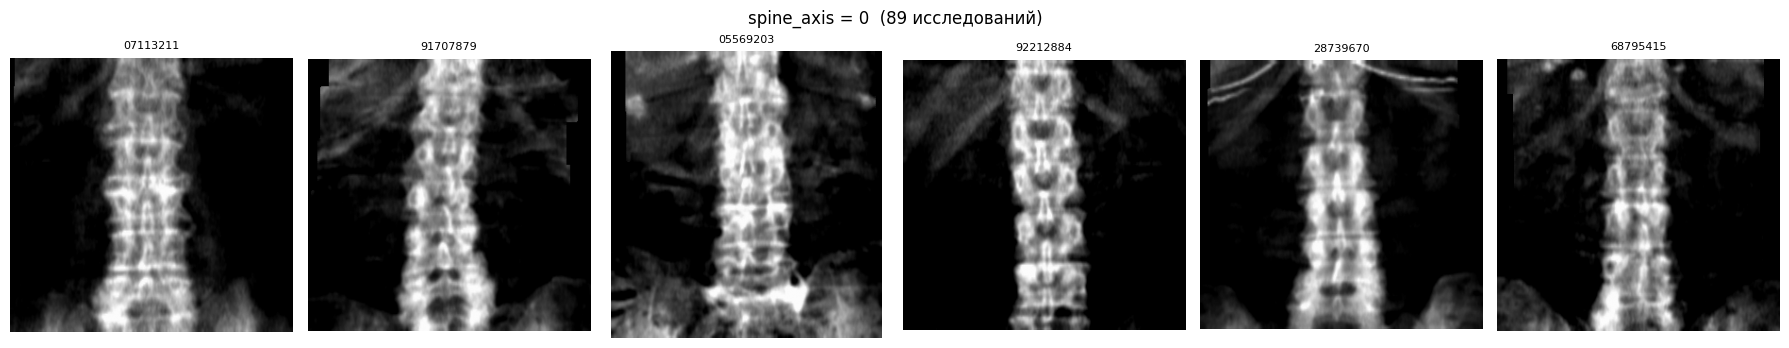

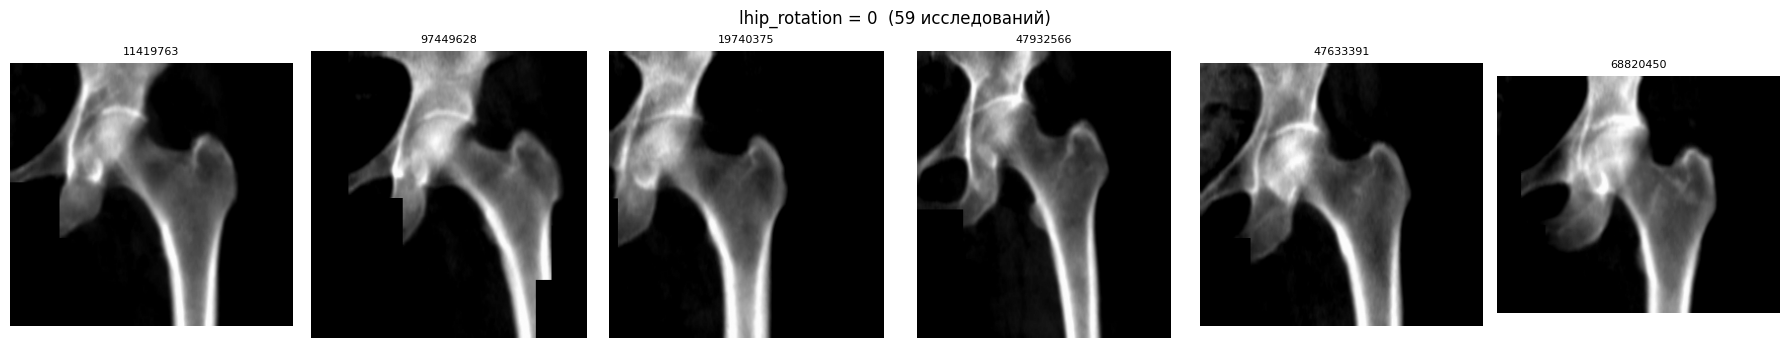

In [19]:
# Нормальные примеры для сравнения
show_gallery('spine_axis', 0, n=6); show_gallery('lhip_rotation', 0, n=6)